# 05. 모델 비교 (TF-IDF+LogReg vs LSTM vs DistilBERT)

세 모델의 test 지표(Accuracy/F1)를 비교표로 만들고 `models/comparison.md`에 저장한다.

비교 구도: **고전 ML(TF-IDF+LogReg) → 비사전학습 DL(LSTM) → 사전학습 DL(DistilBERT)** — 사전학습의 효과를 3단으로 보여준다.

선행 조건: 03(LSTM + TF-IDF), 04(DistilBERT) 실행 완료

In [5]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
from src.config import MODEL_DIR, OUTPUT_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def load(name):
    return json.loads((MODEL_DIR / name / "metrics.json").read_text())

rows = {"TF-IDF+LogReg": load("tfidf_logreg"),
        "LSTM": load("lstm"),
        "DistilBERT": load("distilbert")}
lines = ["| 모델 | Accuracy | F1 |", "|---|---|---|"]
for name, m in rows.items():
    lines.append(f"| {name} | {m['accuracy']:.4f} | {m['f1']:.4f} |")
table = "\n".join(lines)
print(table)
(MODEL_DIR / "comparison.md").write_text(table + "\n")

| 모델 | Accuracy | F1 |
|---|---|---|
| TF-IDF+LogReg | 0.8179 | 0.8125 |
| LSTM | 0.7629 | 0.7532 |
| DistilBERT | 0.8605 | 0.8620 |


133

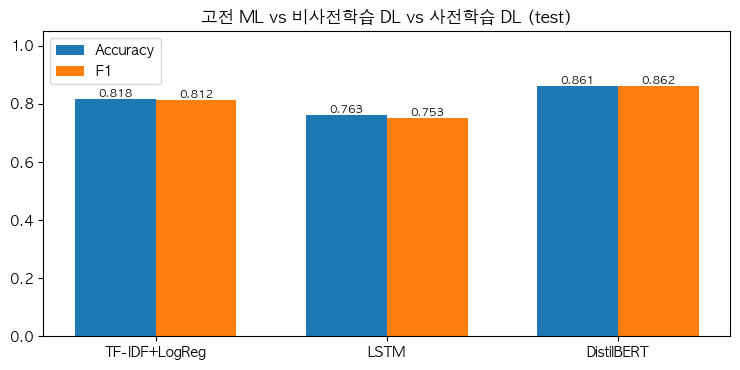

In [6]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

names = list(rows)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
x = range(len(names))
w = 0.35
ax.bar([i - w / 2 for i in x], [rows[n]["accuracy"] for n in names], w, label="Accuracy")
ax.bar([i + w / 2 for i in x], [rows[n]["f1"] for n in names], w, label="F1")
for i, n in enumerate(names):
    ax.text(i - w / 2, rows[n]["accuracy"], f"{rows[n]['accuracy']:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w / 2, rows[n]["f1"], f"{rows[n]['f1']:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(list(x), names)
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("고전 ML vs 비사전학습 DL vs 사전학습 DL (test)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "05_model_comparison_v2.png", dpi=150, bbox_inches="tight")
plt.show()